In [1]:
# pip install yfinance

In [2]:
import yfinance as yf

In [3]:
google_data = yf.download(
    "GOOG",
    period="5y",
    auto_adjust=True
)

[*********************100%***********************]  1 of 1 completed


In [4]:
google_data.head()

Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2021-08-05,135.743195,135.753102,134.414909,134.839662,11866000
2021-08-06,135.838333,135.882000,134.857479,135.103812,13560000
2021-08-09,136.795914,137.112625,135.236421,135.752123,12374000
2021-08-10,136.889572,137.340597,136.027181,136.872722,16034000
2021-08-11,136.486130,137.634256,136.149604,137.074449,15204000


In [5]:
google_data.shape

(1255, 5)

In [7]:
google_data.describe()

Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
count,1255.000000,1255.000000,1255.000000,1255.000000,1.255000e+03
mean,173.167068,175.117584,171.060539,172.989284,2.378786e+07
std,75.329042,76.145412,74.208766,75.119837,1.027373e+07
min,82.760323,85.793584,82.720671,84.762681,4.014887e+06
25%,124.467602,125.959446,123.052579,124.398220,1.726000e+07
50%,145.856537,147.264111,144.484631,145.913504,2.128520e+07
75%,185.773972,187.036504,184.090001,185.633806,2.720135e+07
max,398.799988,404.226718,393.433246,396.821177,9.779860e+07


In [8]:
google_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1255 entries, 2021-08-05 to 2026-08-05
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, GOOG)   1255 non-null   float64
 1   (High, GOOG)    1255 non-null   float64
 2   (Low, GOOG)     1255 non-null   float64
 3   (Open, GOOG)    1255 non-null   float64
 4   (Volume, GOOG)  1255 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.8 KB


In [9]:
google_data.isna().sum()

Price   Ticker
Close   GOOG      0
High    GOOG      0
Low     GOOG      0
Open    GOOG      0
Volume  GOOG      0
dtype: int64

In [6]:
import matplotlib.pyplot as plt
%matplotlib inline

Text(0.5, 1.0, 'Closing price of Google data')

<Figure size 1500x500 with 0 Axes>

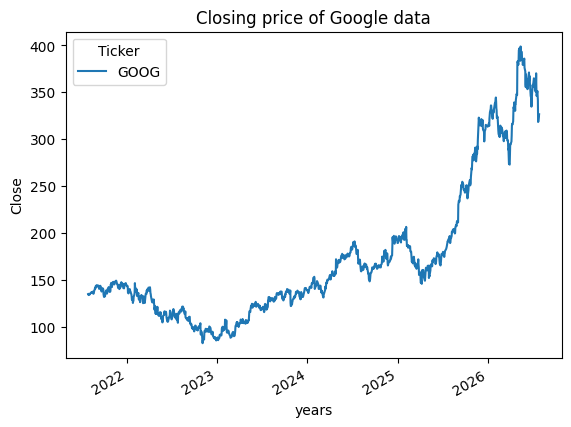

In [8]:
plt.figure(figsize = (15,5))
google_data['Close'].plot()
plt.xlabel("years")
plt.ylabel("Close")
plt.title("Closing price of Google data")

In [9]:
def plot_graph(figsize, values, column_name):
    plt.figure()
    values.plot(figsize = figsize)
    plt.xlabel("years")
    plt.ylabel(column_name)
    plt.title(f"{column_name} of Google data")
    

In [11]:
google_data.columns

MultiIndex([( 'Close', 'GOOG'),
            (  'High', 'GOOG'),
            (   'Low', 'GOOG'),
            (  'Open', 'GOOG'),
            ('Volume', 'GOOG')],
           names=['Price', 'Ticker'])

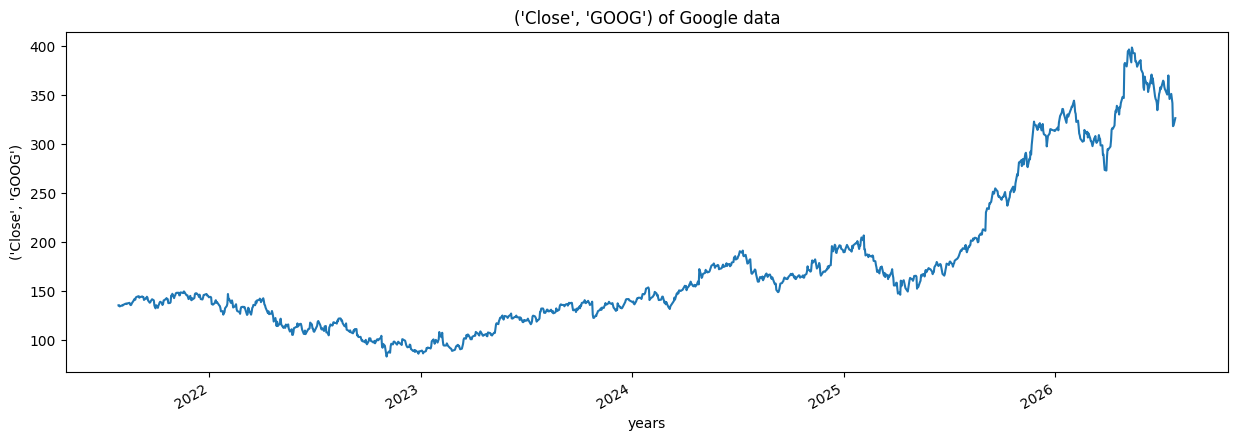

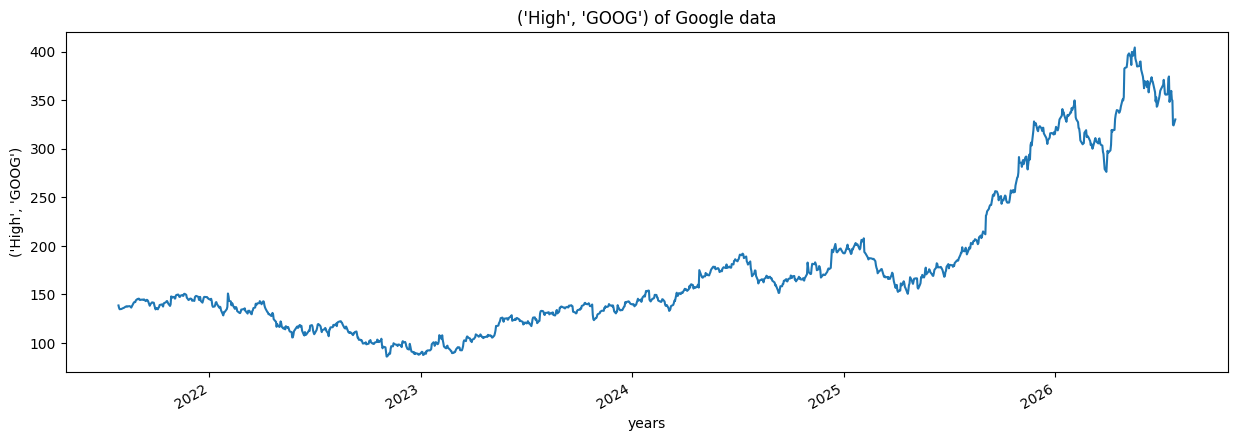

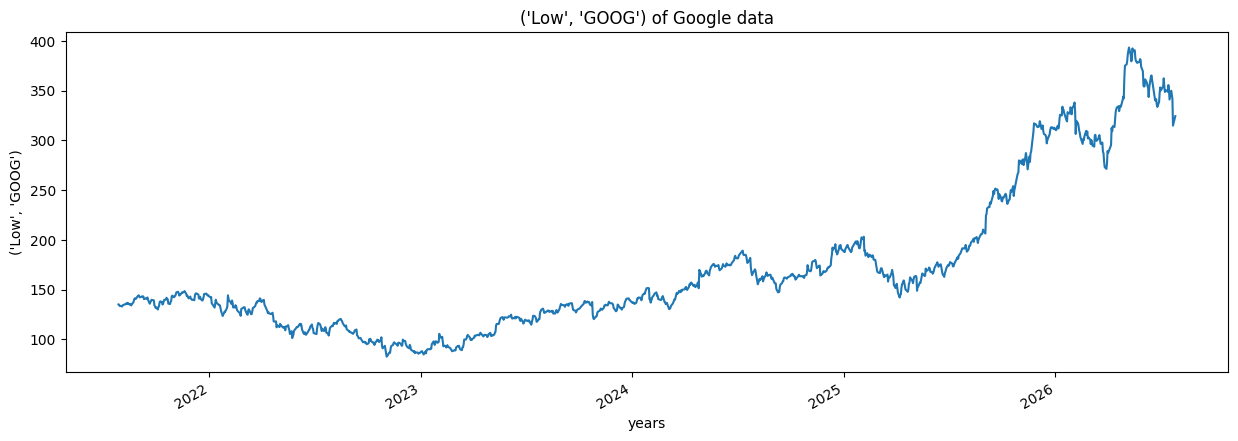

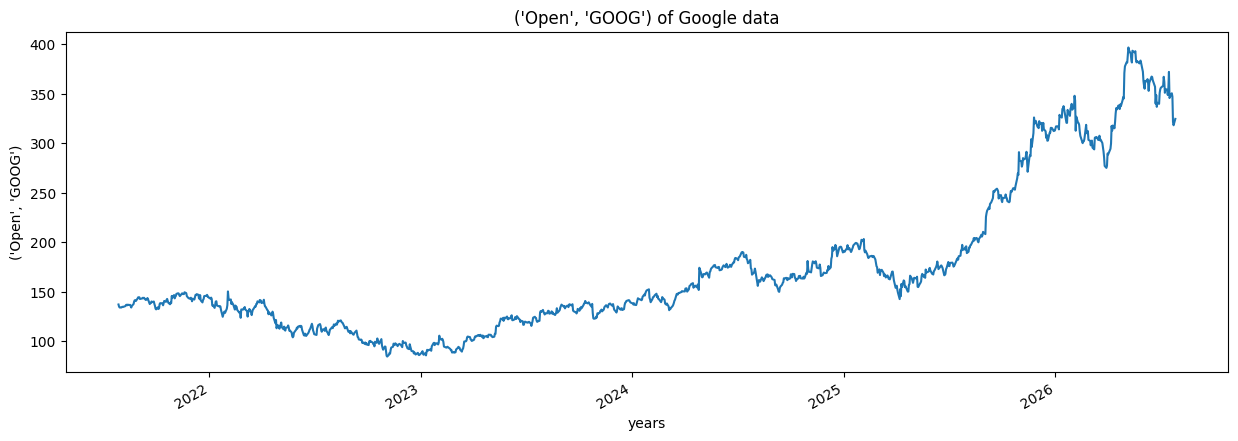

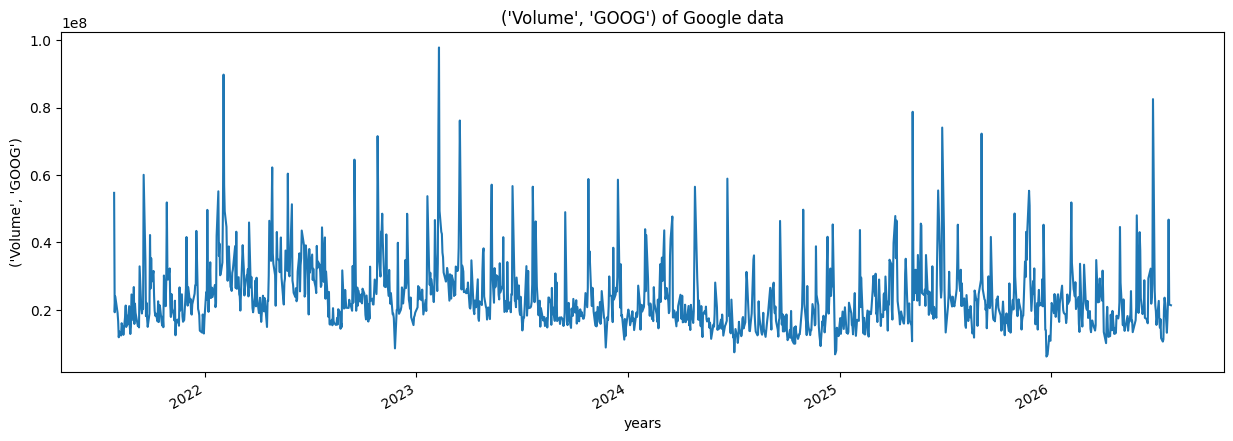

In [12]:
for column in google_data.columns:
    plot_graph((15,5),google_data[column], column)

In [13]:
temp_data = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
print(sum(temp_data[1:6])/5)

40.0


In [15]:
import pandas as pd
data = pd.DataFrame([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
data.head()

,0
0,10
1,20
2,30
3,40
4,50


In [16]:
data['MA'] = data.rolling(5).mean()
data

,0,MA
0,10,NaN
1,20,NaN
2,30,NaN
3,40,NaN
4,50,30.0
5,60,40.0
6,70,50.0
7,80,60.0
8,90,70.0
9,100,80.0


In [17]:
for i in range(2021,2026):
    print(i,list(google_data.index.year).count(i))

2021 110
2022 251
2023 250
2024 252
2025 250


In [18]:
google_data['MA_for_250_days'] = google_data['Close'].rolling(250).mean()

In [19]:
google_data['MA_for_250_days'][0:250].tail()

Date
2022-07-19           NaN
2022-07-20           NaN
2022-07-21           NaN
2022-07-22           NaN
2022-07-25    131.930749
Name: MA_for_250_days, dtype: float64

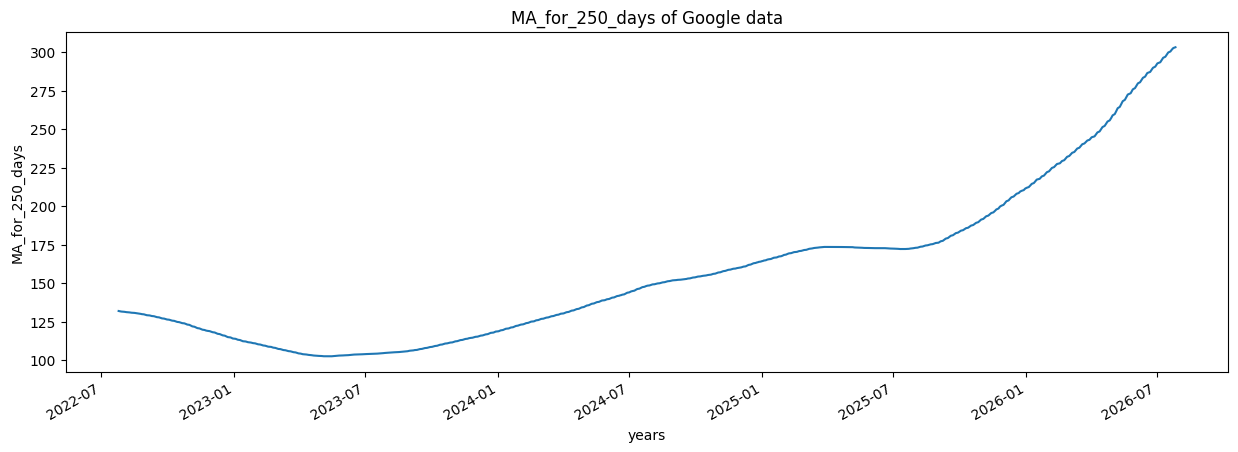

In [20]:
plot_graph((15,5), google_data['MA_for_250_days'], 'MA_for_250_days')

<Figure size 640x480 with 0 Axes>

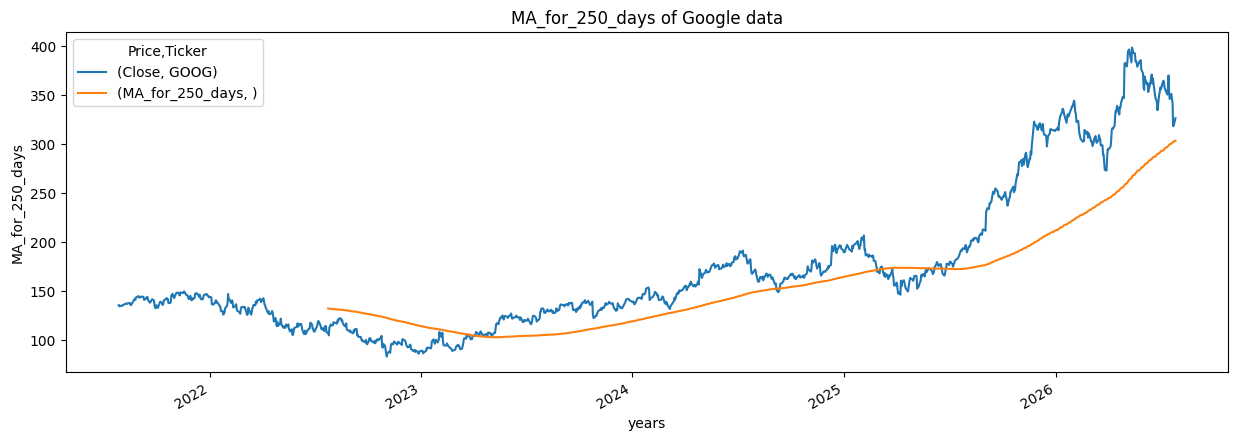

In [21]:
plot_graph((15,5), google_data[['Close','MA_for_250_days']], 'MA_for_250_days')

<Figure size 640x480 with 0 Axes>

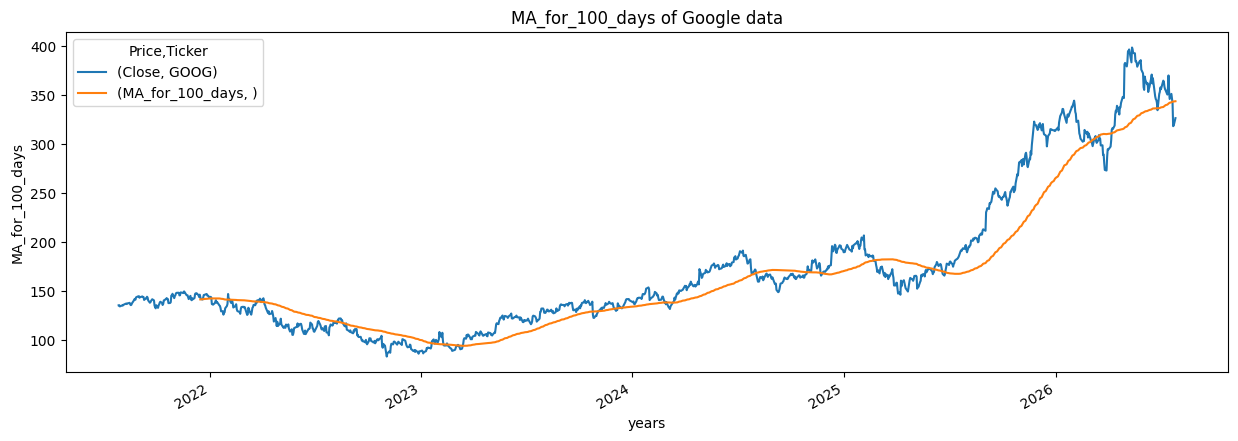

In [22]:
google_data['MA_for_100_days'] = google_data['Close'].rolling(100).mean()
plot_graph((15,5), google_data[['Close','MA_for_100_days']], 'MA_for_100_days')

<Figure size 640x480 with 0 Axes>

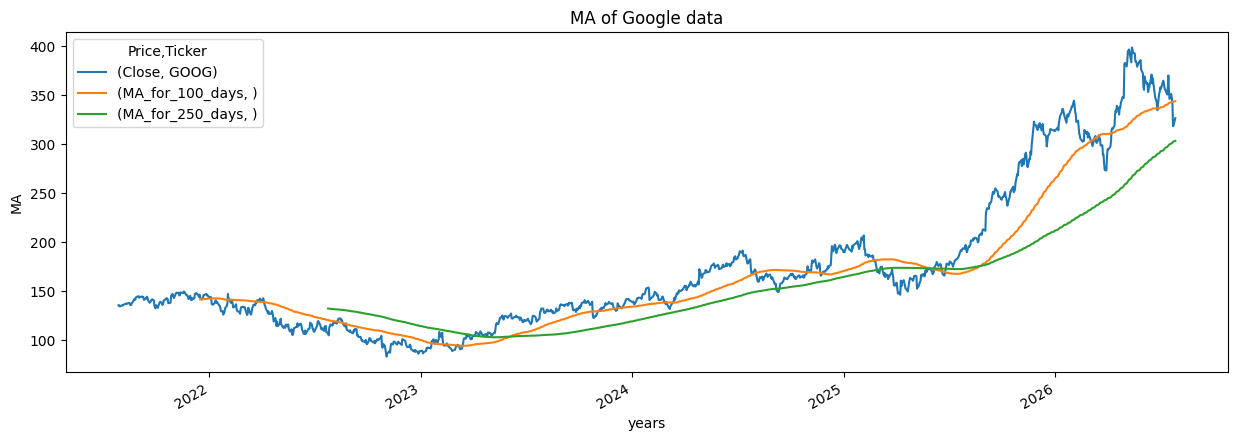

In [23]:
plot_graph((15,5), google_data[['Close','MA_for_100_days', 'MA_for_250_days']], 'MA')

In [24]:
google_data['percentage_change_cp'] = google_data['Close'].pct_change()
google_data[['Close','percentage_change_cp']].head()

Price,Close,percentage_change_cp
Ticker,GOOG,
Date,,
2021-07-28,135.189575,NaN
2021-07-29,135.347183,0.001166
2021-07-30,134.039200,-0.009664
2021-08-02,134.801025,0.005684
2021-08-03,135.088974,0.002136


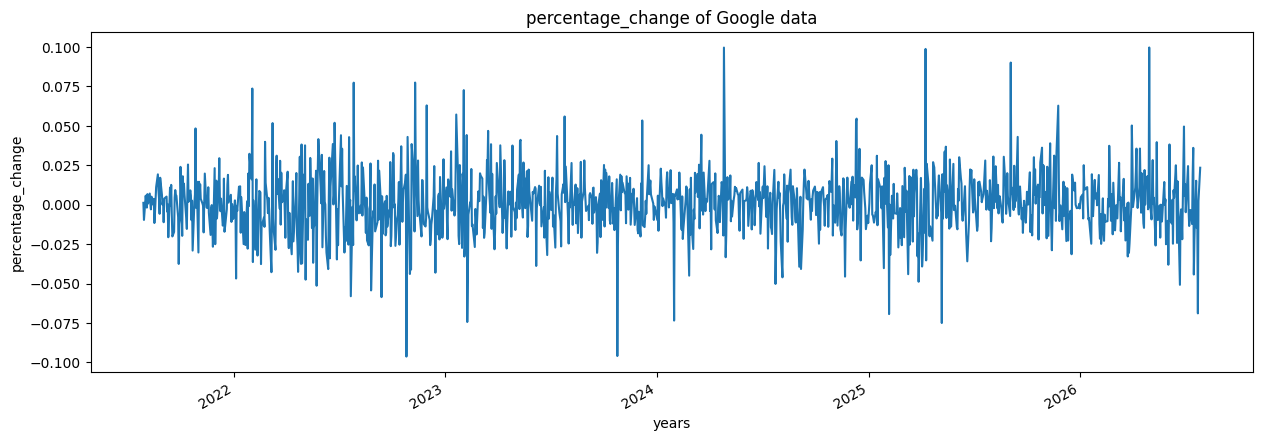

In [25]:
plot_graph((15,5), google_data['percentage_change_cp'], 'percentage_change')

In [26]:
Adj_close_price = google_data[['Close']]

In [27]:
max(Adj_close_price.values),min(Adj_close_price.values) 

(array([398.79998779]), array([82.76033783]))

In [28]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(Adj_close_price)
scaled_data

array([[0.16589449],
       [0.16639319],
       [0.16225452],
       ...,
       [0.74541172],
       [0.74778484],
       [0.77145279]])

In [29]:
len(scaled_data)

1254

In [30]:
x_data = []
y_data = []

for i in range(100, len(scaled_data)):
    x_data.append(scaled_data[i-100:i])
    y_data.append(scaled_data[i])
    
import numpy as np
x_data, y_data = np.array(x_data), np.array(y_data)

In [31]:
x_data[0],y_data[0]

(array([[0.16589449],
        [0.16639319],
        [0.16225452],
        [0.16466506],
        [0.16557617],
        [0.16478731],
        [0.16764628],
        [0.16794722],
        [0.17097716],
        [0.1712736 ],
        [0.16999705],
        [0.17219264],
        [0.1722443 ],
        [0.173844  ],
        [0.16877703],
        [0.16648574],
        [0.16756309],
        [0.17234149],
        [0.18069255],
        [0.18476681],
        [0.18649668],
        [0.18390267],
        [0.19151663],
        [0.19439897],
        [0.19437555],
        [0.19556742],
        [0.19047684],
        [0.19222076],
        [0.19455434],
        [0.19256095],
        [0.1926552 ],
        [0.18326918],
        [0.18811188],
        [0.18792692],
        [0.19357259],
        [0.19096144],
        [0.18183411],
        [0.17416073],
        [0.17613514],
        [0.18018758],
        [0.18297283],
        [0.18550233],
        [0.18195187],
        [0.16527504],
        [0.16005898],
        [0

In [32]:

int(len(x_data)*0.7)

807

In [33]:
4908-100-int(len(x_data)*0.7)

4001

In [34]:
splitting_len = int(len(x_data)*0.7)
x_train = x_data[:splitting_len]
y_train = y_data[:splitting_len]

x_test = x_data[splitting_len:]
y_test = y_data[splitting_len:]

In [35]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(807, 100, 1)
(807, 1)
(347, 100, 1)
(347, 1)


In [36]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

In [37]:
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape=(x_train.shape[1],1)))
model.add(LSTM(64,return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

c:\Users\F CC\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [38]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [39]:
model.fit(x_train, y_train, batch_size=1, epochs = 2)

Epoch 1/2
807/807 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - loss: 6.2983e-04
Epoch 2/2
807/807 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - loss: 3.2933e-04


In [40]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [41]:
predictions = model.predict(x_test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step


In [42]:
predictions

array([[0.29981393],
       [0.2948133 ],
       [0.28606933],
       [0.2814441 ],
       [0.27529863],
       [0.27340502],
       [0.27256274],
       [0.268528  ],
       [0.26821002],
       [0.26804686],
       [0.2691922 ],
       [0.27408022],
       [0.28159958],
       [0.2820111 ],
       [0.27658784],
       [0.262566  ],
       [0.2498329 ],
       [0.24403977],
       [0.24264106],
       [0.23733345],
       [0.22761843],
       [0.22083178],
       [0.21459654],
       [0.22481051],
       [0.2323209 ],
       [0.24063277],
       [0.2485607 ],
       [0.25090244],
       [0.24707195],
       [0.23977101],
       [0.22977448],
       [0.22575548],
       [0.22892308],
       [0.2376014 ],
       [0.24814022],
       [0.25475782],
       [0.25749955],
       [0.2566593 ],
       [0.25649816],
       [0.25950688],
       [0.2629406 ],
       [0.26465458],
       [0.25291952],
       [0.24292198],
       [0.23521802],
       [0.2360186 ],
       [0.24118024],
       [0.252

In [43]:
inv_predictions = scaler.inverse_transform(predictions)
inv_predictions

array([[177.51343],
       [175.93303],
       [173.16959],
       [171.70784],
       [169.76562],
       [169.16716],
       [168.90097],
       [167.62584],
       [167.52534],
       [167.47377],
       [167.83574],
       [169.38055],
       [171.75696],
       [171.88702],
       [170.17305],
       [165.74161],
       [161.71744],
       [159.88658],
       [159.44453],
       [157.76712],
       [154.6968 ],
       [152.55194],
       [150.58136],
       [153.80937],
       [156.18295],
       [158.80983],
       [161.31538],
       [162.05547],
       [160.84488],
       [158.53748],
       [155.37819],
       [154.10803],
       [155.10912],
       [157.8518 ],
       [161.18248],
       [163.27391],
       [164.14041],
       [163.87486],
       [163.82391],
       [164.7748 ],
       [165.85999],
       [166.40167],
       [162.69293],
       [159.53333],
       [157.09856],
       [157.35158],
       [158.98285],
       [162.55333],
       [165.32666],
       [167.60577],


In [44]:
inv_y_test = scaler.inverse_transform(y_test)
inv_y_test

array([[167.13127136],
       [165.3086853 ],
       [168.31645203],
       [164.06373596],
       [166.94204712],
       [165.89630127],
       [162.0120697 ],
       [165.60746765],
       [164.38244629],
       [165.57759094],
       [169.24269104],
       [172.09114075],
       [166.46398926],
       [163.41636658],
       [155.42878723],
       [155.59811401],
       [158.23739624],
       [158.21746826],
       [152.01268005],
       [147.1424408 ],
       [148.63639832],
       [145.98713684],
       [160.40856934],
       [154.74159241],
       [158.7552948 ],
       [160.81692505],
       [158.03819275],
       [154.87106323],
       [152.73971558],
       [149.25387573],
       [153.27754211],
       [157.08209229],
       [160.81692505],
       [163.18728638],
       [161.76307678],
       [161.40454102],
       [160.23927307],
       [162.13157654],
       [165.13937378],
       [165.37841797],
       [164.53182983],
       [152.18199158],
       [155.12007141],
       [153

In [45]:
rmse = np.sqrt(np.mean( (inv_predictions - inv_y_test)**2))

In [46]:
rmse

8.99904295492218

In [47]:
ploting_data = pd.DataFrame(
 {
  'original_test_data': inv_y_test.reshape(-1),
    'predictions': inv_predictions.reshape(-1)
 } ,
    index = google_data.index[splitting_len+100:]
)
ploting_data.head()

,original_test_data,predictions
Date,,
2025-03-10,167.131271,177.513428
2025-03-11,165.308685,175.933029
2025-03-12,168.316452,173.169586
2025-03-13,164.063736,171.707840
2025-03-14,166.942047,169.765625


<Figure size 640x480 with 0 Axes>

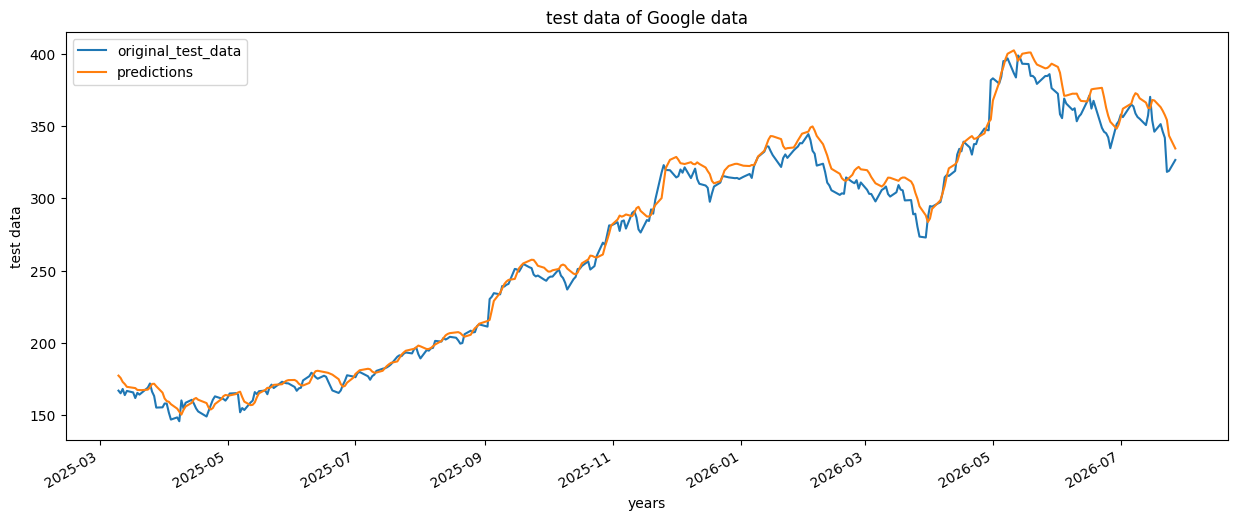

In [48]:
plot_graph((15,6), ploting_data, 'test data')

<Figure size 640x480 with 0 Axes>

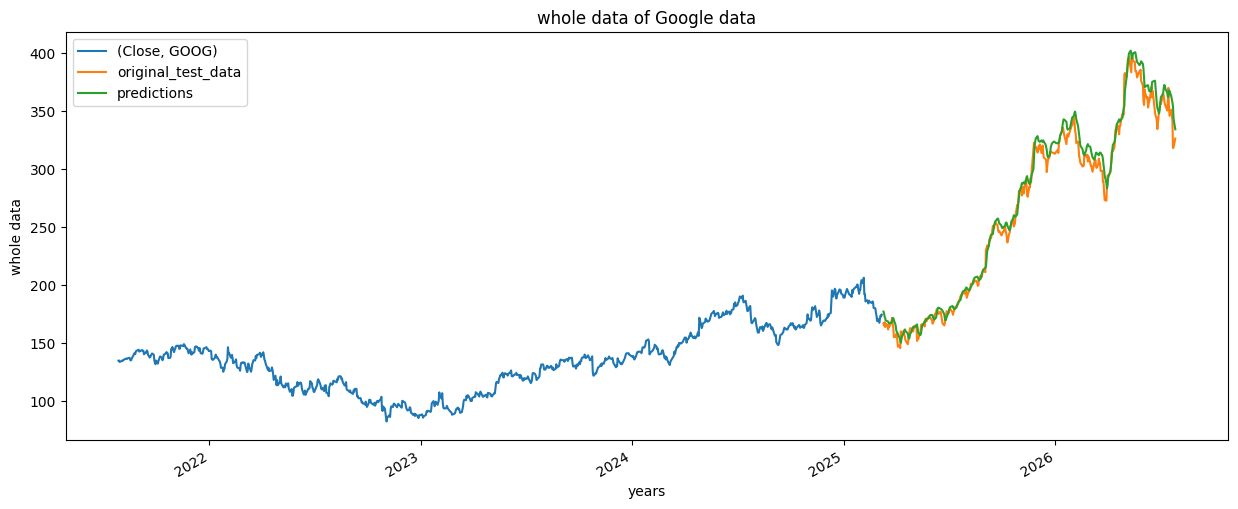

In [49]:
plot_graph((15,6), pd.concat([Adj_close_price[:splitting_len+100],ploting_data], axis=0), 'whole data')

In [50]:
# LSTM MODEL

from sklearn.metrics import r2_score
import numpy as np

# R² Score
r2 = r2_score(inv_y_test, inv_predictions)

# MAPE ও Approximate Accuracy
mape = np.mean(np.abs((inv_y_test - inv_predictions) / inv_y_test)) * 100
accuracy = 100 - mape

# Save Accuracy
lstm_accuracy = accuracy

print(f"RMSE : {rmse:.2f}")
print(f"R² Score : {r2:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"Approximate Accuracy : {accuracy:.2f}%")

RMSE : 9.00
R² Score : 0.9858
MAPE : 2.49%
Approximate Accuracy : 97.51%


In [ ]:
#BIDIRECTIONAL LSTM MODEL

from keras.models import Sequential
from keras.layers import Dense, LSTM, Bidirectional
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

bilstm_model = Sequential()

bilstm_model.add(Bidirectional(LSTM(128, return_sequences=True), input_shape=(100,1)))
bilstm_model.add(Bidirectional(LSTM(64)))
bilstm_model.add(Dense(25))
bilstm_model.add(Dense(1))

bilstm_model.compile(optimizer='adam', loss='mean_squared_error')

bilstm_model.fit(x_train, y_train, batch_size=32, epochs=5)

predictions = bilstm_model.predict(x_test)

predictions = scaler.inverse_transform(predictions)

rmse = np.sqrt(mean_squared_error(inv_y_test, predictions))
mae = mean_absolute_error(inv_y_test, predictions)
r2 = r2_score(inv_y_test, predictions)
mape = np.mean(np.abs((inv_y_test-predictions)/inv_y_test))*100
accuracy = 100 - mape

# Save Results
bilstm_rmse = rmse
bilstm_mae = mae
bilstm_r2 = r2
bilstm_mape = mape
bilstm_accuracy = accuracy

print("Bidirectional LSTM")
print("RMSE :", bilstm_rmse)
print("MAE :", bilstm_mae)
print("R2 Score :", bilstm_r2)
print("MAPE :", bilstm_mape, "%")
print("Approx Accuracy :", bilstm_accuracy, "%")

Epoch 1/5


c:\Users\F CC\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - loss: 0.0046
Epoch 2/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 5.8185e-04
Epoch 3/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 3.0270e-04
Epoch 4/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 2.4274e-04
Epoch 5/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 2.3771e-04
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step
Bidirectional LSTM
RMSE : 12.000064256678014
MAE : 9.307040475630968
R2 Score : 0.9746672509850203
MAPE : 3.505187305732007 %
Approx Accuracy : 96.49481269426799 %


In [ ]:
#GRU MODEL

from keras.models import Sequential
from keras.layers import Dense, GRU
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

gru_model = Sequential()

gru_model.add(GRU(128, return_sequences=True, input_shape=(100,1)))
gru_model.add(GRU(64))
gru_model.add(Dense(25))
gru_model.add(Dense(1))

gru_model.compile(optimizer='adam', loss='mean_squared_error')

gru_model.fit(x_train, y_train, batch_size=32, epochs=5)

predictions = gru_model.predict(x_test)

predictions = scaler.inverse_transform(predictions)

rmse = np.sqrt(mean_squared_error(inv_y_test, predictions))
mae = mean_absolute_error(inv_y_test, predictions)
r2 = r2_score(inv_y_test, predictions)
mape = np.mean(np.abs((inv_y_test - predictions) / inv_y_test)) * 100
accuracy = 100 - mape

#Save Results 
gru_rmse = rmse
gru_mae = mae
gru_r2 = r2
gru_mape = mape
gru_accuracy = accuracy


print("GRU")
print("RMSE :", gru_rmse)
print("MAE :", gru_mae)
print("R2 Score :", gru_r2)
print("MAPE :", gru_mape, "%")
print("Approx Accuracy :", gru_accuracy, "%")



Epoch 1/5


c:\Users\F CC\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 0.0072
Epoch 2/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 3.5215e-04
Epoch 3/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 1.6365e-04
Epoch 4/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 1.4317e-04
Epoch 5/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 1.4904e-04
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
GRU
RMSE : 8.005532279749545
MAE : 6.061862824629638
R2 Score : 0.9887255438131883
MAPE : 2.2842410896010517 %
Approx Accuracy : 97.71575891039895 %


In [55]:
#STACKED LSTM MODEL

from keras.models import Sequential
from keras.layers import Dense, LSTM
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

stacked_lstm = Sequential()

stacked_lstm.add(LSTM(128, return_sequences=True, input_shape=(100,1)))
stacked_lstm.add(LSTM(64, return_sequences=True))
stacked_lstm.add(LSTM(32))
stacked_lstm.add(Dense(25))
stacked_lstm.add(Dense(1))

stacked_lstm.compile(optimizer='adam', loss='mean_squared_error')

stacked_lstm.fit(x_train, y_train, batch_size=32, epochs=5)

predictions = stacked_lstm.predict(x_test)

predictions = scaler.inverse_transform(predictions)

rmse = np.sqrt(mean_squared_error(inv_y_test, predictions))
mae = mean_absolute_error(inv_y_test, predictions)
r2 = r2_score(inv_y_test, predictions)
mape = np.mean(np.abs((inv_y_test - predictions) / inv_y_test)) * 100
accuracy = 100 - mape

#Save Results 
stacked_lstm_rmse = rmse
stacked_lstm_mae = mae
stacked_lstm_r2 = r2
stacked_lstm_mape = mape
stacked_lstm_accuracy = accuracy

print("Stacked LSTM")
print("RMSE :", stacked_lstm_rmse)
print("MAE :", stacked_lstm_mae)
print("R2 Score :", stacked_lstm_r2)
print("MAPE :", stacked_lstm_mape, "%")
print("Approx Accuracy :", stacked_lstm_accuracy, "%")



Epoch 1/5


c:\Users\F CC\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 0.0046
Epoch 2/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 5.6858e-04
Epoch 3/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 4.7459e-04
Epoch 4/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 4.7648e-04
Epoch 5/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 4.7688e-04
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step
Stacked LSTM
RMSE : 24.22192273039595
MAE : 18.600649567090127
R2 Score : 0.896787474249841
MAPE : 6.384743313647336 %
Approx Accuracy : 93.61525668635267 %


In [ ]:
#CNN+LSTM MODEL

from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, LSTM, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

cnn_lstm_model = Sequential()

cnn_lstm_model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu',
        input_shape=(100,1)
    )
)

cnn_lstm_model.add(
    MaxPooling1D(pool_size=2)
)

cnn_lstm_model.add(
    LSTM(64)
)

cnn_lstm_model.add(
    Dense(25)
)

cnn_lstm_model.add(
    Dense(1)
)

cnn_lstm_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

cnn_lstm_model.fit(
    x_train,
    y_train,
    batch_size=32,
    epochs=5
)

predictions = cnn_lstm_model.predict(x_test)

predictions = scaler.inverse_transform(predictions)

rmse = np.sqrt(mean_squared_error(inv_y_test, predictions))
mae = mean_absolute_error(inv_y_test, predictions)
r2 = r2_score(inv_y_test, predictions)
mape = np.mean(np.abs((inv_y_test - predictions) / inv_y_test)) * 100
accuracy = 100 - mape

#Save Results 
cnn_lstm_rmse = rmse
cnn_lstm_mae = mae
cnn_lstm_r2 = r2
cnn_lstm_mape = mape
cnn_lstm_accuracy = accuracy

print("CNN + LSTM")
print("RMSE :", cnn_lstm_rmse)
print("MAE :", cnn_lstm_mae)
print("R2 Score :", cnn_lstm_r2)
print("MAPE :", cnn_lstm_mape, "%")
print("Approx Accuracy :", cnn_lstm_accuracy, "%")


Epoch 1/5


c:\Users\F CC\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0055
Epoch 2/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7.0499e-04
Epoch 3/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.0070e-04
Epoch 4/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.8248e-04
Epoch 5/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.5109e-04
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
CNN + LSTM
RMSE : 14.50201016809118
MAE : 10.889443301330038
R2 Score : 0.9630025673884156
MAPE : 4.014013473961631 %
Approx Accuracy : 95.98598652603837 %


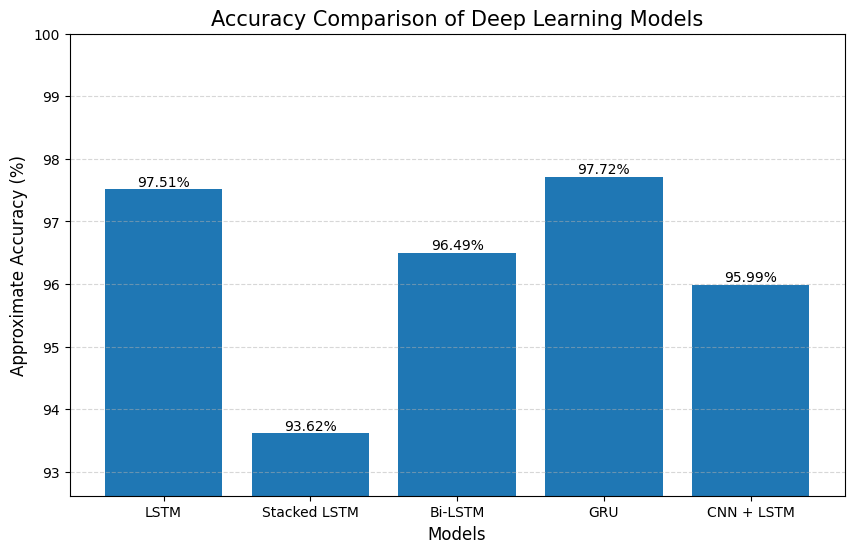

In [56]:
import matplotlib.pyplot as plt

# Model Names
models = [
    "LSTM",
    "Stacked LSTM",
    "Bi-LSTM",
    "GRU",
    "CNN + LSTM"
]

# Accuracy Values
accuracies = [
    lstm_accuracy,
    stacked_lstm_accuracy,
    bilstm_accuracy,
    gru_accuracy,
    cnn_lstm_accuracy
]

plt.figure(figsize=(10,6))

bars = plt.bar(models, accuracies)

plt.title("Accuracy Comparison of Deep Learning Models", fontsize=15)
plt.xlabel("Models", fontsize=12)
plt.ylabel("Approximate Accuracy (%)", fontsize=12)


plt.ylim(min(accuracies)-1, 100)


for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.05,
        f"{height:.2f}%",
        ha='center',
        fontsize=10
    )

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

c:\Users\F CC\Desktop\tonmoy deep learning lab project\stock_price_prediction-main


In [ ]:
model.save("Latest_stock_price_model.keras")